# Rough Kernel Lift Diagnostics

This notebook checks the finite exponential lift used for the rough kernel. The lag `u` is the age of a volatility shock.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gamma, roots_genlaguerre
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def find_project_root(start=None):
    here = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root containing src/ and notebooks/.")


PROJECT_ROOT = find_project_root()
OUT = PROJECT_ROOT / "outputs" / "comparisons" / "rough_kernel_lift_diagnostics"
OUT.mkdir(parents=True, exist_ok=True)

H = 0.20
BASELINE_L = 8
five_minutes_days = 5 / (24 * 60)
realised_max_maturity_days = 65.44
screen_max_maturity_days = 120.0
check_days = np.array([five_minutes_days, 1.0, 7.0, 30.0, realised_max_maturity_days, screen_max_maturity_days])
check_labels = ["5 min", "1 day", "7 days", "30 days", "65.44 days", "120 days"]
u_days = np.geomspace(five_minutes_days, screen_max_maturity_days, 800)
u_years = u_days / 365.0

## Baseline Lift

The baseline rough filter uses `H = 0.20` and `L = 8`.

In [3]:
def lift_nodes_weights(H_value, L_value):
    alpha = -(H_value + 0.5)
    nodes, raw_weights = roots_genlaguerre(L_value, alpha)
    weights = raw_weights * np.exp(nodes) / gamma(0.5 - H_value)
    return nodes, weights


def true_kernel(u, H_value):
    return np.asarray(u, dtype=float) ** (H_value - 0.5)


def lifted_kernel(u, H_value, L_value):
    u = np.asarray(u, dtype=float)
    nodes, weights = lift_nodes_weights(H_value, L_value)
    return np.sum(weights[:, None] * np.exp(-nodes[:, None] * u[None, :]), axis=0)


nodes, weights = lift_nodes_weights(H, BASELINE_L)
lift_table = pd.DataFrame({"ell": np.arange(1, BASELINE_L + 1), "x_l": nodes, "w_l": weights})
lift_table.to_csv(OUT / "rough_kernel_lift_nodes_weights_H020_L8.csv", index=False)
display(lift_table)

,ell,x_l,w_l
0,1,0.042100,0.733813
1,2,0.589532,0.414973
2,3,1.767982,0.338134
3,4,3.626561,0.301789
4,5,6.256942,0.283624
5,6,9.825224,0.278541
6,7,14.662560,0.289316
7,8,21.629100,0.339554


## Kernel Error

The true kernel is compared with the finite exponential approximation over lags from five minutes to 120 calendar days.

In [4]:
kernel_true = true_kernel(u_years, H)
kernel_lift = lifted_kernel(u_years, H, BASELINE_L)
relative_error = np.abs(kernel_lift - kernel_true) / kernel_true

diagnostics = pd.DataFrame(
    {
        "u_days": u_days,
        "u_years": u_years,
        "true_kernel": kernel_true,
        "lifted_kernel": kernel_lift,
        "relative_error": relative_error,
    }
)
diagnostics.to_csv(OUT / "rough_kernel_lift_error_curve_H020_L8.csv", index=False)

point_check = pd.DataFrame(
    {
        "lag": check_labels,
        "lag_days": check_days,
        "true_kernel": true_kernel(check_days / 365.0, H),
        "lifted_kernel": lifted_kernel(check_days / 365.0, H, BASELINE_L),
    }
)
point_check["relative_error_pct"] = 100.0 * np.abs(point_check["lifted_kernel"] - point_check["true_kernel"]) / point_check["true_kernel"]
point_check.to_csv(OUT / "rough_kernel_lift_point_checks_H020_L8.csv", index=False)
display(point_check.round(4))

,lag,lag_days,true_kernel,lifted_kernel,relative_error_pct
0,5 min,0.0035,32.1000,2.9796,90.7179
1,1 day,1.0000,5.8707,2.9312,50.0700
2,7 days,7.0000,3.2746,2.6768,18.2550
3,30 days,30.0000,2.1162,2.0809,1.6661
4,65.44 days,65.4400,1.6747,1.6736,0.0670
5,120 days,120.0000,1.3962,1.3961,0.0004


## Lift Dimension

This compares the baseline `L = 8` lift with richer deterministic lifts.

In [5]:
L_values = [8, 16, 24, 32, 48]
comparison_rows = []
for L_value in L_values:
    lift_points = lifted_kernel(check_days / 365.0, H, L_value)
    true_points = true_kernel(check_days / 365.0, H)
    ratio_points = lift_points / true_points
    error_points = 100.0 * np.abs(lift_points - true_points) / true_points
    row = {"L": L_value}
    for label, ratio, error in zip(check_labels, ratio_points, error_points):
        row[f"{label} ratio"] = ratio
        row[f"{label} error, %"] = error
    comparison_rows.append(row)

lift_dimension_table = pd.DataFrame(comparison_rows)
lift_dimension_table.to_csv(OUT / "rough_kernel_lift_ratio_and_error_by_L_H020.csv", index=False)
display(lift_dimension_table.round(4))

,L,5 min ratio,"5 min error, %",1 day ratio,"1 day error, %",7 days ratio,"7 days error, %",30 days ratio,"30 days error, %",65.44 days ratio,"65.44 days error, %",120 days ratio,"120 days error, %"
0,8,0.0928,90.7179,0.4993,50.0700,0.8174,18.2550,0.9833,1.6661,0.9993,0.0670,1.0,0.0004
1,16,0.1166,88.3361,0.6160,38.4032,0.9264,7.3649,0.9991,0.0870,1.0000,0.0002,1.0,0.0000
2,24,0.1328,86.7184,0.6888,31.1247,0.9671,3.2947,0.9999,0.0052,1.0000,0.0000,1.0,0.0000
3,32,0.1455,85.4541,0.7410,25.9007,0.9845,1.5463,1.0000,0.0003,1.0000,0.0000,1.0,0.0000
4,48,0.1651,83.4881,0.8127,18.7256,0.9963,0.3672,1.0000,0.0000,1.0000,0.0000,1.0,0.0000


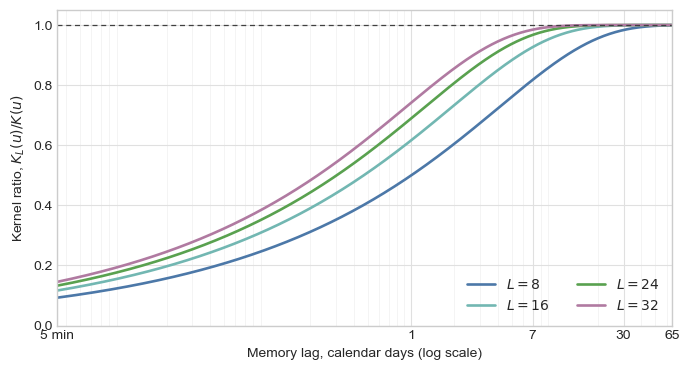

In [6]:
plot_L_values = [8, 16, 24, 32]
plot_mask = u_days <= realised_max_maturity_days
plot_days = u_days[plot_mask]
plot_years = plot_days / 365.0
plot_true = true_kernel(plot_years, H)
palette = {8: "#4C78A8", 16: "#72B7B2", 24: "#59A14F", 32: "#B07AA1"}

fig, ax = plt.subplots(figsize=(7.0, 3.8))
for L_value in plot_L_values:
    ratio_curve = lifted_kernel(plot_years, H, L_value) / plot_true
    ax.semilogx(plot_days, ratio_curve, color=palette[L_value], linewidth=1.9, label=fr"$L={L_value}$")

ax.axhline(1.0, color="0.25", linestyle=(0, (4, 3)), linewidth=0.9)
for day in [1.0, 7.0, 30.0, realised_max_maturity_days]:
    ax.axvline(day, color="0.78", linestyle=":", linewidth=0.7, zorder=0)
ax.set_xlim(five_minutes_days, realised_max_maturity_days)
ax.set_ylim(0.0, 1.05)
ax.set_xticks([five_minutes_days, 1.0, 7.0, 30.0, realised_max_maturity_days])
ax.set_xticklabels(["5 min", "1", "7", "30", "65"])
ax.set_xlabel("Memory lag, calendar days (log scale)")
ax.set_ylabel(r"Kernel ratio, $K_L(u)/K(u)$")
ax.legend(frameon=False, ncol=2, loc="lower right")
ax.grid(True, which="major", color="0.88", linewidth=0.8)
ax.grid(True, which="minor", axis="x", color="0.94", linewidth=0.5)
fig.tight_layout()
fig.savefig(OUT / "rough_kernel_lift_ratio_by_L_H020_smooth.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT / "rough_kernel_lift_ratio_by_L_H020_smooth.pdf", bbox_inches="tight")
plt.show()

## H Sensitivity

Changing `H` changes both the target roughness and the deterministic lift.

,H,L,"5 min error, %","1 day error, %","7 days error, %","30 days error, %","65.44 days error, %","120 days error, %"
0,0.1,8,95.8891,61.1991,24.6095,2.4644,0.1043,0.0007
1,0.2,8,90.7179,50.0700,18.2550,1.6661,0.0670,0.0004
2,0.3,8,79.2525,36.3570,11.9415,0.9916,0.0379,0.0002


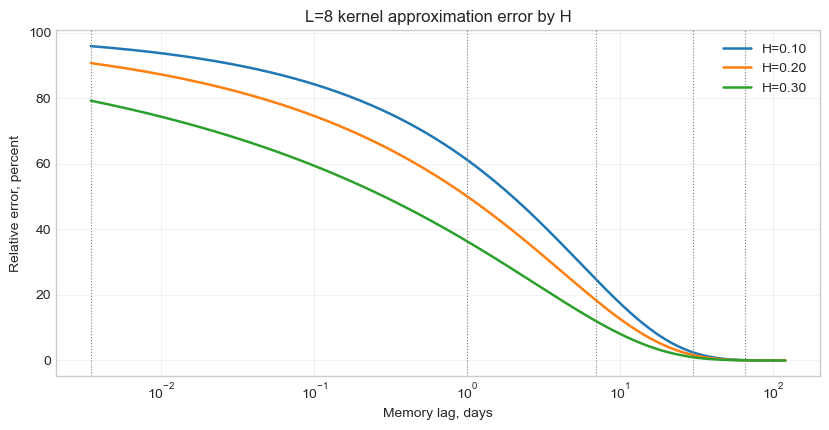

In [7]:
H_values = [0.10, 0.20, 0.30]
rows = []
for H_value in H_values:
    true_points = true_kernel(check_days / 365.0, H_value)
    lift_points = lifted_kernel(check_days / 365.0, H_value, BASELINE_L)
    errors = 100.0 * np.abs(lift_points - true_points) / true_points
    row = {"H": H_value, "L": BASELINE_L}
    for label, error in zip(check_labels, errors):
        row[f"{label} error, %"] = error
    rows.append(row)

h_error_table = pd.DataFrame(rows)
h_error_table.to_csv(OUT / "rough_kernel_lift_error_by_H_L8.csv", index=False)
display(h_error_table.round(4))

fig, ax = plt.subplots(figsize=(8.4, 4.4))
for H_value in H_values:
    curve_true = true_kernel(u_years, H_value)
    curve_lift = lifted_kernel(u_years, H_value, BASELINE_L)
    ax.semilogx(u_days, 100.0 * np.abs(curve_lift - curve_true) / curve_true, linewidth=1.8, label=f"H={H_value:.2f}")
for day in [five_minutes_days, 1.0, 7.0, 30.0, realised_max_maturity_days]:
    ax.axvline(day, color="0.5", linestyle=":", linewidth=0.8)
ax.set_xlabel("Memory lag, days")
ax.set_ylabel("Relative error, percent")
ax.set_title("L=8 kernel approximation error by H")
ax.legend(frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / "rough_kernel_lift_error_by_H_L8.png", dpi=220, bbox_inches="tight")
plt.show()

## Exported Files

Tables and figures are written to `outputs/comparisons/rough_kernel_lift_diagnostics`.